### Create transaction before doing anything first :3

In [ ]:
from utils.preprocess import create_transactions
from utils.postprocess import map_movie_id_to_title
import pandas as pd
# transaction_list = create_transactions_from_ratings(r'/home/hinhnv/Hai/KDLVKP/data_mining_code/data/movielens_20m/rating.csv', save_path='/home/hinhnv/Hai/KDLVKP/data_mining_code/data/movielens_20m/transaction.pkl')
transaction_list = create_transactions(r'/home/hinhnv/Hai/KDLVKP/data_mining_code/data/movielens_1m/ratings.csv',
                                       chunk_size=1000000,
                                    #    save_path='/home/hinhnv/Hai/KDLVKP/data_mining_code/data/movielens_1m/transaction.pkl'
                                       )

In [2]:
import pickle as pkl
with open('/home/hinhnv/Hai/KDLVKP/data_mining_code/data/movielens_1m/transaction.pkl', 'rb') as f:
    transaction_list = pkl.load(f)
len(transaction_list)

6038

### Guide to run Apriori algorithm

In [4]:
from algorithms.apriori import Apriori
import pickle as pkl

# with open('/home/hinhnv/Hai/KDLVKP/data_mining_code/data/movielens_1m/transaction.pkl', 'rb') as f:
#     transaction_list = pkl.load(f)

apriori = Apriori(min_support=0.2, min_confidence=0.5)
apriori.fit(transaction_list)

Generating 1-itemsets


Generated 53 1-itemsets
Generating 2-itemsets
Generated 52 frequent 2-itemsets
Generating 3-itemsets
Generated 3 frequent 3-itemsets
Generating 4-itemsets
Generated 0 frequent 4-itemsets


In [5]:
len(apriori.frequent_itemsets)

108

In [ ]:
# apriori.frequent_itemsets
map_movie_id_to_title(apriori.frequent_itemsets)

### Guide to run Hashtree Apriori algorithm

In [9]:
from algorithms.hashtree_apriori import HashTreeApriori

hash_tree_apriori = HashTreeApriori(min_support=0.3, min_confidence=0.5, max_leaf_size=64, max_depth=4)
hash_tree_apriori.fit(transaction_list)

Finding frequent 1-itemsets...
Generated 19 frequent 1-itemsets
Finding frequent 2-itemsets...
Generated 171 candidate 2-itemsets
Found 1 frequent 2-itemsets
Finding frequent 3-itemsets...


In [10]:
# hash_tree_apriori.frequent_itemsets
hash_tree_apriori.frequent_itemsets

[({110}, 0.3274263000993706),
 ({260}, 0.43424975157336865),
 ({318}, 0.3388539251407751),
 ({527}, 0.34299436899635644),
 ({589}, 0.33852268963232857),
 ({593}, 0.37297118251076516),
 ({608}, 0.3434912222590262),
 ({858}, 0.3294137131500497),
 ({1196}, 0.41570056310036435),
 ({1197}, 0.31864855912553824),
 ({1198}, 0.3742961245445512),
 ({1210}, 0.35226896323285856),
 ({1270}, 0.31632991056641274),
 ({1617}, 0.31069890692282215),
 ({2028}, 0.3742961245445512),
 ({2396}, 0.3108645246770454),
 ({2571}, 0.35955614441868167),
 ({2762}, 0.35823120238489564),
 ({2858}, 0.47250745279894),
 ({260, 1196}, 0.32461079827757533)]

### Guide to run FP-Growth algorithm

In [12]:
from algorithms.fp_growth import FPGrowth
# Same interface as Apriori
fp_growth = FPGrowth(min_support=0.3, min_confidence=0.5)
fp_growth.fit(transaction_list)

# Get results
fp_growth.get_frequent_itemsets

# Save/load results
# fp_growth.save_results('fp_growth_results.pkl')

Found 19 frequent items
Found 20 frequent itemsets
Generating association rules...
Generated 2 association rules


<bound method FPGrowth.get_frequent_itemsets of <algorithms.fp_growth.FPGrowth object at 0x7757ca595c30>>

In [13]:
fp_growth.frequent_itemsets


[({1617}, 0.31069890692282215),
 ({2396}, 0.3108645246770454),
 ({1270}, 0.31632991056641274),
 ({1197}, 0.31864855912553824),
 ({110}, 0.3274263000993706),
 ({858}, 0.3294137131500497),
 ({589}, 0.33852268963232857),
 ({318}, 0.3388539251407751),
 ({527}, 0.34299436899635644),
 ({608}, 0.3434912222590262),
 ({1210}, 0.35226896323285856),
 ({2762}, 0.35823120238489564),
 ({2571}, 0.35955614441868167),
 ({593}, 0.37297118251076516),
 ({1198}, 0.3742961245445512),
 ({2028}, 0.3742961245445512),
 ({1196}, 0.41570056310036435),
 ({260, 1196}, 0.32461079827757533),
 ({260}, 0.43424975157336865),
 ({2858}, 0.47250745279894)]

In [ ]:
fp_growth.frequent_itemsets
map_movie_id_to_title(fp_growth.frequent_itemsets)

### Guide to run Content-based filtering algorithm (quite computation-exhaustive)

#### Embedding movies & users using multiprocessing
We can use create_user_embedding method in utils.create_embedding to create user embeddings, but that implementation does not support multi-processing.

In [1]:
import numpy as np
import pandas as pd
import pickle
from tqdm import tqdm
import multiprocessing as mp # For multiprocessing

# Worker function for multiprocessing. Must be defined at the top level.
def process_user_embedding_task(user_id, user_specific_ratings_df, all_movie_embeddings, embedding_s):
    """Calculates embedding for a single user."""
    user_emb = np.zeros(embedding_s)
    denom = 0
    
    mean_rating = user_specific_ratings_df['rating'].mean()
    std_rating = user_specific_ratings_df['rating'].std()
    
    for _, rated_row in user_specific_ratings_df.iterrows():
        movie_id = rated_row['movieId']
        actual_rating = rated_row['rating']

        # IMPORTANT: Check if movie_id exists in movie_embeddings
        if movie_id in all_movie_embeddings:
            current_movie_embedding = all_movie_embeddings[movie_id]
            # Ensure it's a numpy array and has the expected shape
            if isinstance(current_movie_embedding, np.ndarray) and current_movie_embedding.shape == embedding_s:
                if np.any(current_movie_embedding) and actual_rating: # Check if embedding is not all zeros
                    normalized_rating = (actual_rating - mean_rating) / (std_rating + 1e-6)  # Scale to [-1, 1]
                    denom += actual_rating
                    user_emb += normalized_rating * current_movie_embedding

    if denom > 0:
        user_emb /= denom
    return user_id, user_emb

def create_user_embedding(ratings_file_path: str = 'data/movielens_20m/rating.csv', 
                          movie_embedding_path: str = 'data/movielens_20m/movie_embedding.pkl',
                          save_path: str = 'data/movielens_20m/user_embedding.pkl'):
    
    try:
        rating = pd.read_csv(ratings_file_path)
        # movies_df = pd.read_csv(movie_file_path) # Not directly used in current embedding logic
    except FileNotFoundError as e:
        print(f"Error: Could not read ratings file. {e}")
        return {}
    
    try:
        with open(movie_embedding_path, 'rb') as f:
            movie_embeddings = pickle.load(f)
    except FileNotFoundError:
        print(f"Error: Movie embedding file not found at {movie_embedding_path}")
        return {}
    except Exception as e:
        print(f"Error loading movie_embeddings: {e}")
        return {}
        
    user_embedding = {}
    
    # Robustly determine embedding shape
    _embedding_shape = None
    if not movie_embeddings or not isinstance(movie_embeddings, dict) or len(movie_embeddings) == 0:
        print("Error: movie_embeddings is empty, not a dictionary, or invalid. Cannot proceed.")
        return {}
    
    # Try to get shape from the first valid NumPy array embedding
    for key in movie_embeddings: # Iterate to find the first valid embedding
        if isinstance(movie_embeddings[key], np.ndarray):
            _embedding_shape = movie_embeddings[key].shape
            break 
    
    if _embedding_shape is None:
        print("Error: Could not determine a valid embedding shape from movie_embeddings (no NumPy arrays found as values).")
        return {}
    
    print(f"Determined embedding shape: {_embedding_shape}")

    # Prepare arguments for each task for multiprocessing
    tasks_args = []
    # Grouping by userId is efficient as each worker gets only the data it needs for one user
    grouped_ratings = rating.groupby('userId')
    for user_id_val, group_df in grouped_ratings:
        tasks_args.append((user_id_val, group_df, movie_embeddings, _embedding_shape))

    if not tasks_args:
        print("No users found in ratings data to process.")
        return {}

    # Determine number of processes
    # Using mp.cpu_count() can be aggressive; mp.cpu_count() // 2 or mp.cpu_count() - 1 is often a good start
    num_processes = max(1, mp.cpu_count() // 2) 
    print(f"Starting user embedding computation with {num_processes} processes for {len(tasks_args)} users...")

    results = []
    # Create a pool of worker processes
    # The `if __name__ == "__main__":` guard is crucial for multiprocessing on some OS (like Windows)
    # when running scripts. For Jupyter notebooks, it's usually not needed for the pool itself,
    # but the worker function must be defined at the top-level.
    try:
        with mp.Pool(processes=num_processes) as pool:
            # Use tqdm for progress bar. pool.starmap executes tasks and returns results in order.
            results = list(tqdm(pool.starmap(process_user_embedding_task, tasks_args), total=len(tasks_args), desc="Processing users"))
    except Exception as e:
        print(f"An error occurred during multiprocessing: {e}")
        print("Consider if the worker function or data being passed is picklable.")
        # Optionally, you could add a fallback to single-threaded processing here for debugging:
        # print("Falling back to single-threaded processing due to error.")
        # results = []
        # for args_tuple in tqdm(tasks_args, desc="Single-threaded fallback"):
        #     results.append(process_user_embedding_task(*args_tuple))


    for res_user_id, res_user_emb in results:
        user_embedding[res_user_id] = res_user_emb

    print(f"Finished processing embeddings for {len(user_embedding)} users.")
    
    if save_path:
        try:
            with open(save_path, 'wb') as f:
                pickle.dump(user_embedding, f)
                print(f"User embeddings saved to {save_path}")
        except Exception as e:
            print(f"Error saving user embeddings to {save_path}: {e}")
    
    return user_embedding


In [2]:
# movie_embeddings_path = 'data/movielens_20m/movie_embedding.pkl'

# use this optimized version of create_user_embedding function
user_embeddings_path = 'data/movielens_20m/user_embedding.pkl'
user_embeddings = create_user_embedding(ratings_file_path='data/movielens_20m/ratings.csv', 
                                        movie_embedding_path='data/movielens_20m/movie_embedding.pkl',
                                        save_path=user_embeddings_path)

Determined embedding shape: (384,)
Starting user embedding computation with 28 processes for 138493 users...


Processing users: 100%|██████████| 138493/138493 [00:00<00:00, 2395734.41it/s]


Finished processing embeddings for 138493 users.
User embeddings saved to data/movielens_20m/user_embedding.pkl


In [3]:
import os
import sys
from algorithms.content_based_filtering import ContentBasedFiltering
create_embeddings_kwargs = {
    'movies_file_path': 'data/movielens_20m/movies_processed.csv',
    'model_name': 'all-MiniLM-L6-v2',
    'item_embedding_save_path': 'data/movielens_20m/movie_embedding.pkl',
    'ratings_file_path': 'data/movielens_20m/ratings.csv',
    'movie_embedding_path': 'data/movielens_20m/movie_embedding.pkl',
    'user_embedding_save_path': 'data/movielens_20m/user_embedding.pkl'
}
content_based_filtering = ContentBasedFiltering(
                                                user_embedding_path='data/movielens_20m/user_embedding.pkl', 
                                                item_embedding_path='data/movielens_20m/movie_embedding.pkl',
                                                user_item_interaction_path='data/movielens_20m/user_movies.pkl',
                                                # **create_embeddings_kwargs
                                                )

/home/hinhnv/Hai/KDLVKP/data_mining_code/kdlvkp_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import pickle as pkl
with open('data/movielens_20m/movie_embedding.pkl', 'rb') as f:
    movie_embedding = pkl.load(f)


In [8]:
import pandas as pd
def load_movie_mapping():
    """Load movie ID to name mapping"""
    movies_df = pd.read_csv('data/movielens_20m/movie.csv')
    movie_mapping = dict(zip(movies_df['movieId'], movies_df['title']))

    return movie_mapping

In [12]:
user_id = 2
def convert_to_implicit_user_id(user_id):
    return user_id - 1
implicit_user_id = convert_to_implicit_user_id(user_id)
movie_id_to_title = load_movie_mapping()
# note that the recommend method returns the index of the movie (explicit indices)
recommended_movie_id = content_based_filtering.recommend(user_id=implicit_user_id, top_k=50)

/home/hinhnv/Hai/KDLVKP/data_mining_code/utils/metrics.py:14: RuntimeWarning: invalid value encountered in divide
  return a @ b.T / (np.linalg.norm(a, axis=1, keepdims=True) * np.linalg.norm(b, axis=1, keepdims=True).T)


In [13]:
recommended_movies = [movie_id_to_title[movie_id] for movie_id in recommended_movie_id]

In [14]:
recommended_movies

['No Good Deed (2014)',
 'Cast a Dark Shadow (Angel) (1955)',
 'Across the Hall (2009)',
 'Cucaracha, La (1998)',
 'Moth Diaries, The (2011)',
 'Jeopardy (a.k.a. A Woman in Jeopardy) (1953)',
 'Hard to Be a God (2013)',
 'Fourth State, The (Die vierte Macht) (2012)',
 'Prodigal Son, The (Tuhlaajapoika) (1992)',
 'Hypnotist, The (Hypnotisören) (2012)',
 'Piggy (2012)',
 'Alien Nation: Millennium (1996)',
 "King's Game (Kongekabale) (2004)",
 'Valley of the Dragons (1961)',
 'Omega Doom (1996)',
 'Death and Cremation (2010)',
 'Shape of Things to Come, The (1979)',
 'Trois (2000)',
 'Calling, The (2014)',
 'Avenger (2006)',
 'Pitfall (1948)',
 'Railroaded! (1947)',
 'Zodiac (2014)',
 'Wicked (1998)',
 'Christmas on Mars (2008)',
 'Big Knife, The (1955)',
 'Operation Ganymed (1977)',
 'Twin Sitters (1994)',
 'EMR (2004)',
 'Cottage, The (2012)',
 'Claustrofobia (2011)',
 'Trip to Mars, A (1910)',
 'Storage (2009)',
 'Deceived (1991)',
 'Killers from Space (1954)',
 'Terror on a Train (Tim

In [9]:
import pandas as pd

def get_top_rated_movies_for_user(user_id, top_n=10):
    """
    Retrieve the top N movies rated by a specific user along with movie information.
    
    Parameters:
    -----------
    user_id : int
        The ID of the user
    top_n : int, optional
        Number of top rated movies to return (default: 10)
        
    Returns:
    --------
    DataFrame containing the user's top rated movies with movie information
    """
    ratings_df = pd.read_csv('data/movielens_20m/ratings.csv')
    movies_df = pd.read_csv('data/movielens_20m/movies_processed.csv')
    

    user_ratings = ratings_df[ratings_df['userId'] == user_id]
    user_ratings = user_ratings.sort_values(by='rating', ascending=False)
    
    top_rated = user_ratings.head(top_n)

    result = pd.merge(top_rated, movies_df, on='movieId')
    result = result[['movieId', 'title', 'genres', 'rating']]
    
    return result

In [10]:
get_top_rated_movies_for_user(user_id=1, top_n=50)

,movieId,title,genres,rating
0,4993,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy,5.0
1,8507,Freaks (1932),Crime|Drama|Horror,5.0
2,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy,5.0
3,5952,"Lord of the Rings: The Two Towers, The (2002)",Adventure|Fantasy,5.0
4,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,4.5
5,1198,Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure,4.5
6,8636,Spider-Man 2 (2004),Action|Adventure|Sci-Fi|IMAX,4.5
7,1036,Die Hard (1988),Action|Crime|Thriller,4.0
8,1200,Aliens (1986),Action|Adventure|Horror|Sci-Fi,4.0
9,1097,E.T. the Extra-Terrestrial (1982),Children|Drama|Sci-Fi,4.0


In [21]:
from collections import defaultdict
import pickle
import os

def extract_user_movies(ratings_file_path, output_pickle_path=None,
                        # rating_threshold=3.0,
                        rating_threshold=None,
                        chunk_size=1000000):
    """
    Optimized version of extract_user_movies with significant performance improvements.
    
    Key optimizations:
    1. Larger chunk size for better I/O efficiency
    2. Vectorized operations instead of iterrows()
    3. More efficient data structures
    4. Reduced memory allocations
    5. Optional parallel processing
    """
    
    print(f"Processing ratings from: {ratings_file_path}")
    
    # Use regular dict with list comprehension for better performance
    user_movies = {}
    
    if not os.path.exists(ratings_file_path):
        raise FileNotFoundError(f"Ratings file not found: {ratings_file_path}")
    
    try:
        # Read file info first to estimate progress
        total_lines = sum(1 for _ in open(ratings_file_path)) - 1  # Subtract header
        print(f"Total ratings to process: {total_lines:,}")
        
        chunk = pd.read_csv(ratings_file_path, nrows=chunk_size)
        
       
        # Apply rating threshold using vectorized operation
        if rating_threshold is not None:
            chunk = chunk[chunk['rating'] >= rating_threshold]
        
        # OPTIMIZATION 1: Use vectorized groupby instead of iterrows()
        # This is much faster than iterating row by row
        grouped = chunk.groupby('userId')['movieId'].apply(list).to_dict()
        
        # OPTIMIZATION 2: Merge dictionaries efficiently
        for user_id, movie_list in grouped.items():
            if user_id in user_movies:
                # Use set operations for faster merging and deduplication
                user_movies[user_id].update(movie_list)
            else:
                user_movies[user_id] = set(movie_list)
    
    except Exception as e:
        print(f"Error reading file: {e}")
        return {}
    
    # OPTIMIZATION 3: Convert sets to lists in one go
    user_movies_dict = {user_id: list(movie_set) for user_id, movie_set in user_movies.items()}
    
    print(f"\nExtraction Summary:")
    print(f"- Total users: {len(user_movies_dict):,}")
    if user_movies_dict:
        avg_movies = sum(len(movies) for movies in user_movies_dict.values()) / len(user_movies_dict)
        print(f"- Average movies per user: {avg_movies:.2f}")
    
    # Generate output path if not provided
    if output_pickle_path is None:
        base_name = os.path.splitext(os.path.basename(ratings_file_path))[0]
        output_dir = os.path.dirname(ratings_file_path)
        threshold_suffix = f"_threshold_{rating_threshold}" if rating_threshold else ""
        output_pickle_path = os.path.join(output_dir, f"{base_name}_user_movies{threshold_suffix}.pkl")
    
    # OPTIMIZATION 4: Use protocol 4 for faster pickle serialization
    try:
        with open(output_pickle_path, 'wb') as f:
            pickle.dump(user_movies_dict, f, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"\nUser-movie mappings saved to: {output_pickle_path}")
        print(f"File size: {os.path.getsize(output_pickle_path) / 1024 / 1024:.2f} MB")
    except Exception as e:
        print(f"Error saving pickle file: {e}")
        return user_movies_dict
    
    return user_movies_dict

In [ ]:
extract_user_movies(ratings_file_path='data/movielens_20m/ratings.csv', output_pickle_path='data/movielens_20m/user_movies.pkl')

In [43]:
import pickle as pkl
with open('/home/hinhnv/Hai/KDLVKP/data_mining_code/data/movielens_20m/user_movies.pkl', 'rb') as f:
    user_movies_dict = pkl.load(f)

In [42]:
user_movies_dict = extract_user_movies('/home/hinhnv/Hai/KDLVKP/data_mining_code/data/movielens_20m/ratings.csv', output_pickle_path='/home/hinhnv/Hai/KDLVKP/data_mining_code/data/movielens_20m/user_movies.pkl')

Processing ratings from: /home/hinhnv/Hai/KDLVKP/data_mining_code/data/movielens_20m/ratings.csv
Total ratings to process: 20,000,263

Extraction Summary:
- Total users: 6,743
- Average movies per user: 148.30

User-movie mappings saved to: /home/hinhnv/Hai/KDLVKP/data_mining_code/data/movielens_20m/user_movies.pkl
File size: 2.90 MB


### Colaborative filtering

In [ ]:
import numpy as np
import pandas as pd
from utils.preprocess import create_user_item_matrix
from algorithms.colab_filtering import ColabFiltering

user_item_matrix, user_id_list, movie_id_list = create_user_item_matrix(
    ratings_file='data/movielens_20m/ratings.csv'
)

/home/hinhnv/Hai/KDLVKP/data_mining_code/kdlvkp_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pickle as pkl
with open('/home/hinhnv/Hai/KDLVKP/data_mining_code/data/movielens_20m/user_item_matrix.pkl', 'wb') as f:
    pkl.dump(user_item_matrix, f)
with open('/home/hinhnv/Hai/KDLVKP/data_mining_code/data/movielens_20m/user_id_list.pkl', 'wb') as f:
    pkl.dump(user_id_list, f)
with open('/home/hinhnv/Hai/KDLVKP/data_mining_code/data/movielens_20m/movie_id_list.pkl', 'wb') as f:
    pkl.dump(movie_id_list, f)


In [3]:
# Strategies: 'user_based', 'item_based'
# Similarity metrics: 'cosine', 'pearson'
k_neighbors = 5
colab_filter_user_based_cosine = ColabFiltering(strategy='item_based', similarity_metric='cosine', k=k_neighbors)
colab_filter_user_based_cosine.fit(user_item_matrix)

/home/hinhnv/Hai/KDLVKP/data_mining_code/algorithms/colab_filtering.py:52: RuntimeWarning: invalid value encountered in divide
  pred = np.where(denom>0, nom/denom, -np.inf)
/home/hinhnv/Hai/KDLVKP/data_mining_code/algorithms/colab_filtering.py:52: RuntimeWarning: divide by zero encountered in divide
  pred = np.where(denom>0, nom/denom, -np.inf)


In [4]:
def load_movie_mapping():
    """Load movie ID to name mapping"""
    movies_df = pd.read_csv('data/movielens_20m/movie.csv')
    movie_mapping = dict(zip(movies_df['movieId'], movies_df['title']))

    return movie_mapping

In [5]:
movie_id_to_title = load_movie_mapping()

In [6]:
user_id = 1
def convert_to_implicit_user_id(user_id):
    return user_id - 1
implicit_user_id = convert_to_implicit_user_id(user_id)

# remember that colab filtering returns the index of the movie in the user_item_matrix (implicit indices)
recommended_movie_implicit_ids = colab_filter_user_based_cosine.recommend(user_id=implicit_user_id, top_k=50)
recommended_movie_id = [movie_id_list[i] for i in recommended_movie_implicit_ids]
recommended_movies = [movie_id_to_title[movie_id] for movie_id in recommended_movie_id]

In [7]:
recommended_movies

['Star Trek IV: The Voyage Home (1986)',
 'Garden State (2004)',
 '2010: The Year We Make Contact (1984)',
 'Sneakers (1992)',
 'Galaxy Quest (1999)',
 'Star Trek III: The Search for Spock (1984)',
 'Titanic (1997)',
 'Lost in Translation (2003)',
 'Toy Story 2 (1999)',
 'Star Trek V: The Final Frontier (1989)',
 'Hellboy (2004)',
 'Royal Tenenbaums, The (2001)',
 'Green Mile, The (1999)',
 'Cowboy Bebop: The Movie (Cowboy Bebop: Tengoku no Tobira) (2001)',
 'High Fidelity (2000)',
 'Big Fish (2003)',
 'Wallace & Gromit: The Wrong Trousers (1993)',
 'Repo Man (1984)',
 'Life Is Beautiful (La Vita è bella) (1997)',
 'Total Recall (1990)',
 'Almost Famous (2000)',
 'Chicken Run (2000)',
 'Finding Neverland (2004)',
 'Harry Potter and the Half-Blood Prince (2009)',
 'Fear and Loathing in Las Vegas (1998)',
 'Traffic (2000)',
 'House of Flying Daggers (Shi mian mai fu) (2004)',
 'Full Monty, The (1997)',
 'Eternal Sunshine of the Spotless Mind (2004)',
 'Star Trek VI: The Undiscovered Coun

In [31]:
movies.head()

,movieId,title,genres,user_tags,genome_tags
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Watched|computer animation|Disney animated fea...,3d|action|adventure|affectionate|animal movie|...
1,2,Jumanji (1995),Adventure|Children|Fantasy,time travel|adapted from:book|board game|child...,action|adapted from:book|adventure|animal movi...
2,3,Grumpier Old Men (1995),Comedy|Romance,old people that is actually funny|sequel fever...,chase|comedy|crappy sequel|destiny|family|fish...
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,chick flick|revenge|characters|chick flick|cha...,adultery|betrayal|chick flick|divorce|feel goo...
4,5,Father of the Bride Part II (1995),Comedy,Diane Keaton|family|sequel|Steve Martin|weddin...,catastrophe|chase|comedy|crappy sequel|culture...


In [33]:
movies = pd.read_csv('data/movielens_20m/movies_processed.csv')
all_tags = []
for index, row in movies.iterrows():
    movie_tags = row['genres'].split('|')
    all_tags.extend(movie_tags)

tag_counts = pd.Series(all_tags).value_counts()
tag_counts = tag_counts.sort_values(ascending=False)
tag_counts.head(10)


Drama          13344
Comedy          8374
Thriller        4178
Romance         4127
Action          3520
Crime           2939
Horror          2611
Documentary     2471
Adventure       2329
Sci-Fi          1743
Name: count, dtype: int64

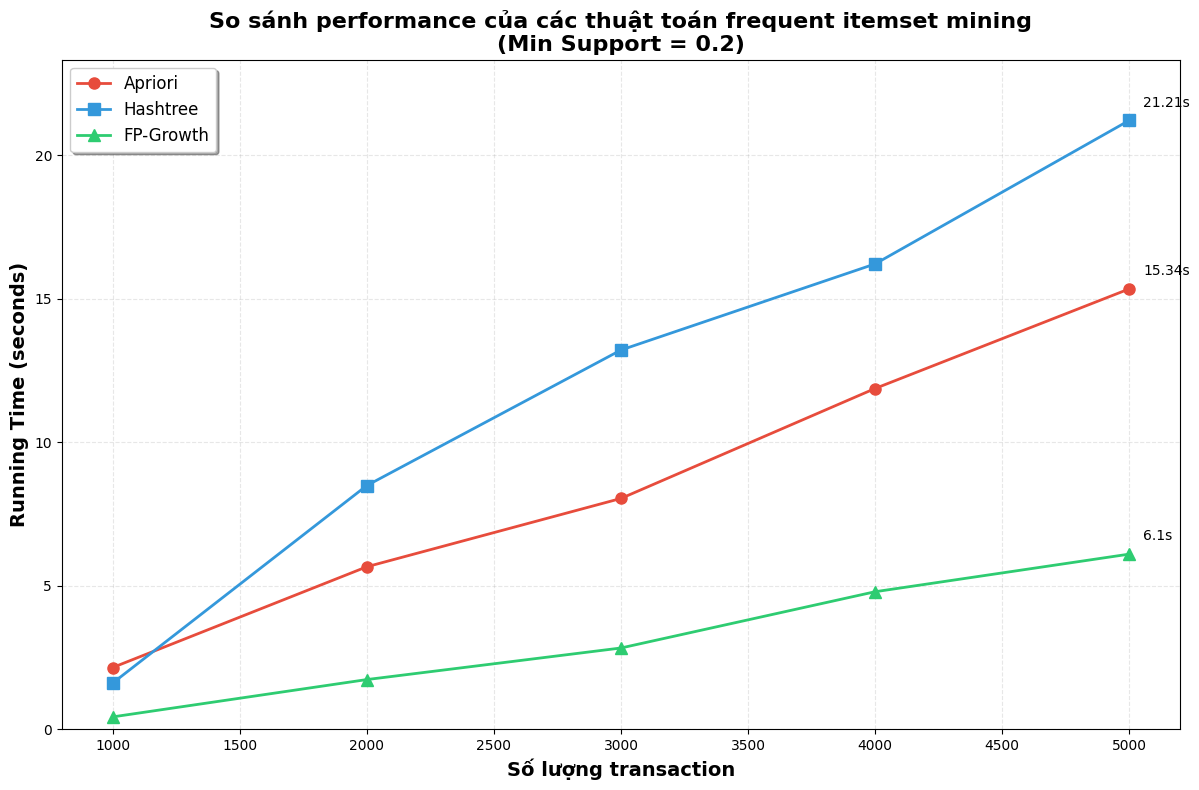

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
transactions = [1000, 2000, 3000, 4000, 5000]
apriori_times = [2.15, 5.66, 8.04, 11.87, 15.34]
hashtree_times = [1.61, 8.49, 13.21, 16.21, 21.21]
fp_growth_times = [0.43, 1.73, 2.83, 4.79, 6.1]

# Create the plot
plt.figure(figsize=(12, 8))

# Plot lines for each algorithm
plt.plot(transactions, apriori_times, 'o-', linewidth=2, markersize=8, label='Apriori', color='#e74c3c')
plt.plot(transactions, hashtree_times, 's-', linewidth=2, markersize=8, label='Hashtree', color='#3498db')
plt.plot(transactions, fp_growth_times, '^-', linewidth=2, markersize=8, label='FP-Growth', color='#2ecc71')

# Customize the plot
plt.xlabel('Số lượng transaction', fontsize=14, fontweight='bold')
plt.ylabel('Running Time (seconds)', fontsize=14, fontweight='bold')
plt.title('So sánh performance của các thuật toán frequent itemset mining\n(Min Support = 0.2)', fontsize=16, fontweight='bold')

# Add grid for better readability
plt.grid(True, alpha=0.3, linestyle='--')

# Customize legend
plt.legend(fontsize=12, loc='upper left', frameon=True, fancybox=True, shadow=True)

# Set axis limits with some padding
plt.xlim(800, 5200)
plt.ylim(0, max(max(apriori_times), max(hashtree_times), max(fp_growth_times)) * 1.1)

# Add some styling
plt.tight_layout()

# Optional: Add annotations for the final values
plt.annotate(f'{apriori_times[-1]}s', 
             xy=(transactions[-1], apriori_times[-1]), 
             xytext=(10, 10), textcoords='offset points',
             fontsize=10, ha='left')
plt.annotate(f'{hashtree_times[-1]}s', 
             xy=(transactions[-1], hashtree_times[-1]), 
             xytext=(10, 10), textcoords='offset points',
             fontsize=10, ha='left')
plt.annotate(f'{fp_growth_times[-1]}s', 
             xy=(transactions[-1], fp_growth_times[-1]), 
             xytext=(10, 10), textcoords='offset points',
             fontsize=10, ha='left')

# Show the plot
plt.show()

# Optional: Save the plot
# plt.savefig('algorithm_performance_comparison.png', dpi=300, bbox_inches='tight')